# PROVA PRÁTICA: IMPLEMENTAÇÃO DE REDE NEURAL PARA CLASSIFICAÇÃO

# **Objetivo**
Implementar uma rede neural artificial para classificação usando Python e TensorFlow/Keras que possa classificar espécies de flores de íris com pelo menos 90% de precisão.

**Conjunto de dados:** Conjunto de dados da flor de íris (disponível no scikit-learn)

**Requisitos mínimos:**
Precisão do teste ≥ 90%

O modelo deve usar pelo menos duas camadas ocultas

Deve incluir visualização dos resultados

Enviar código comentado e análise dos resultados

# ENTREGA OBRIGATÓRIA

*   Código Python (.py ou .ipynb) com implementação completa
*   Saída da execução mostrando:
Precisão do treinamento e dos testes,
Relatório de classificação,
Gráficos gerados
*   Breve análise (5 a 10 linhas) explicando os resultados e possíveis melhorias


**Principais funções que você precisará:**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# **GUIA DE ETAPAS**

# PASSO 1: CONFIGURAÇÃO INICIAL

Importe as bibliotecas necessárias (NumPy, Pandas, Matplotlib, Scikit-learn, TensorFlow/Keras)


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# PASSO 2: CARREGAMENTO E EXPLORAÇÃO DE DADOS

Carregue o conjunto de dados Iris do Scikit-Learn usando o codigo  ou baixar desde: https://archive.ics.uci.edu/dataset/53/iris

Examine a forma dos dados (número de amostras, características)

Identifique as características e classes do conjunto de dados

Crie um DataFrame para análise exploratória



In [4]:
# Pode carregar o conjunto de dados Iris diretamente desde Scikit-Learn
from sklearn.datasets import load_iris
iris = load_iris()

# ETAPA 3: ANÁLISE EXPLORATÓRIA

Exibir estatísticas descritivas (média, desvio padrão, percentis)

Visualizar a distribuição das classes

Criar gráficos de dispersão para visualizar as relações entre as características

Gerar uma matriz de correlação

--- Estatísticas Descritivas ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


--- Distribuição das Classes ---
spec

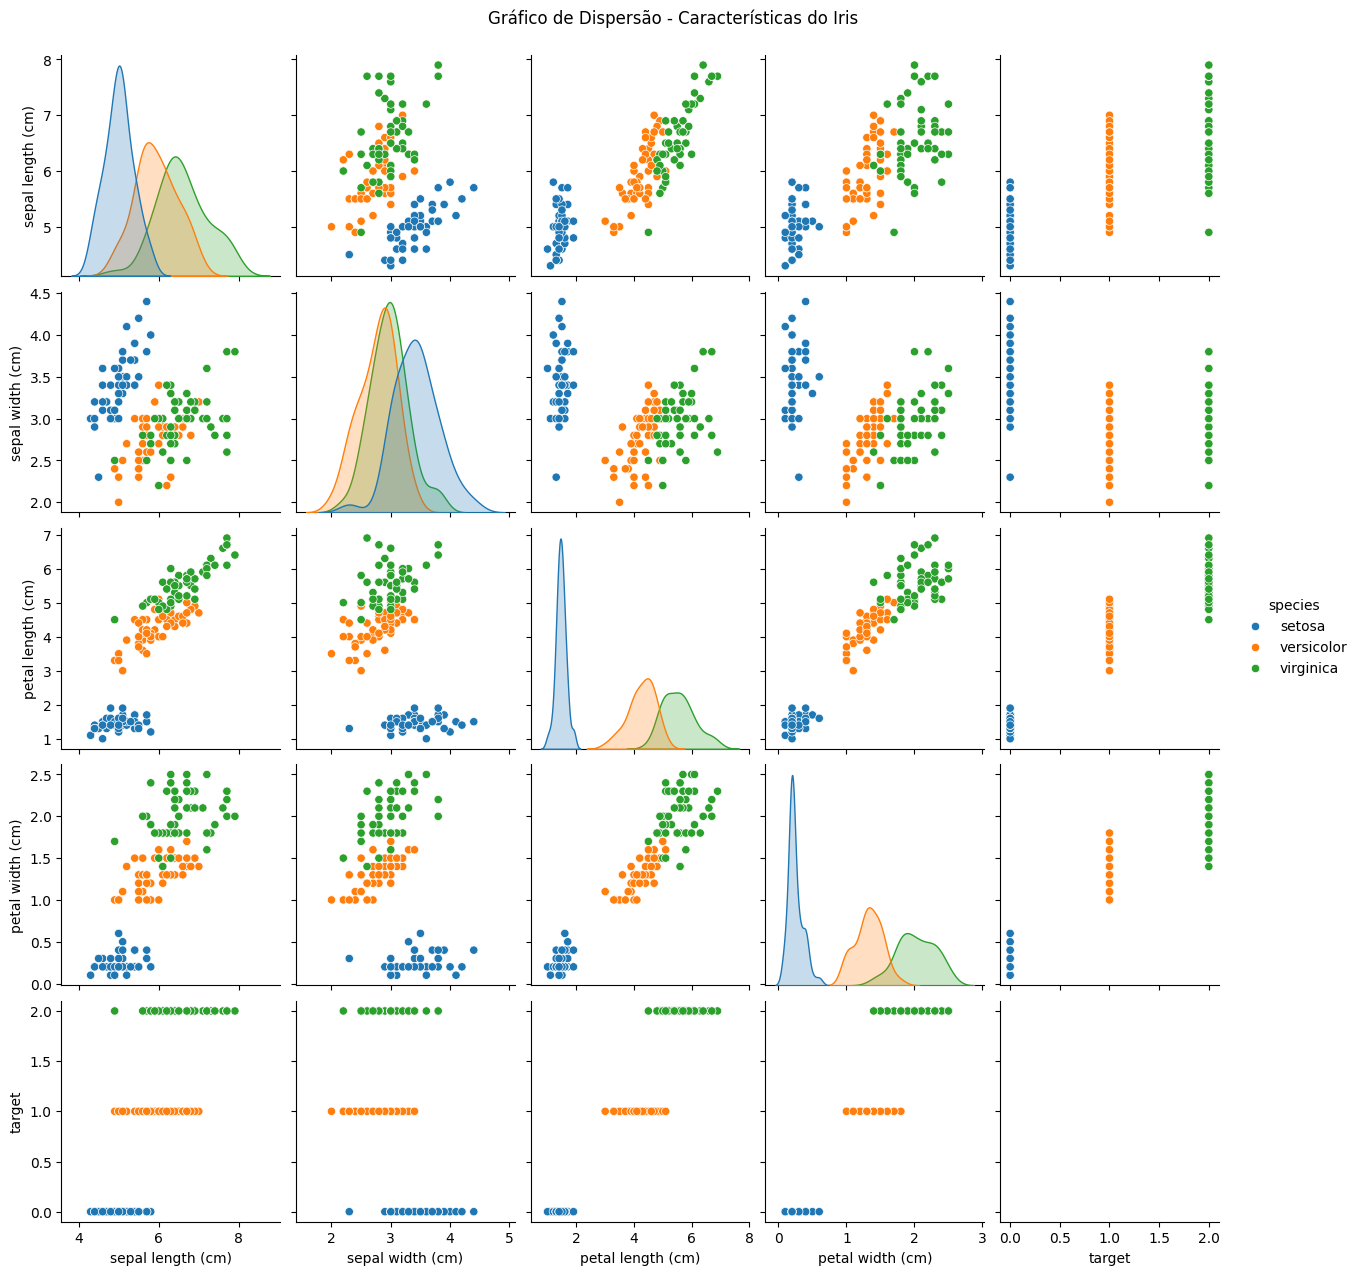

--- Matriz de Correlação ---


ValueError: could not convert string to float: 'setosa'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("--- Estatísticas Descritivas ---")
print(iris_df.describe())
print("\n")

print("--- Distribuição das Classes ---")
print(iris_df['species'].value_counts())
print("\n")

print("--- Gráficos de Dispersão ---")
sns.pairplot(iris_df, hue='species', diag_kind='kde')
plt.suptitle('Gráfico de Dispersão - Características do Iris', y=1.02)
plt.show()

print("--- Matriz de Correlação ---")
correlation_matrix = iris_df.drop(columns=['target']).corr()
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características do Iris')
plt.show()

# PASSO 4: PRÉ-PROCESSAMENTO


Divida os dados em treinamento (80%) e teste (20%) com estratificação

Padronize/Normalize os recursos (CRÍTICO para redes neurais!)

Converta rótulos para codificação one-hot para classificação múltipla

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

iris = load_iris()
X = iris.data  
y = iris.target  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Divisão dos Dados ---")
print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos rótulos de treino (y_train): {y_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")
print(f"Formato dos rótulos de teste (y_test): {y_test.shape}")
print("\n")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Dados Padronizados ---")
print(f"Média das características de treino após padronização: {X_train_scaled.mean(axis=0)}")
print(f"Desvio padrão das características de treino após padronização: {X_train_scaled.std(axis=0)}")
print("\n")

encoder = OneHotEncoder(sparse_output=False)

y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

y_train_one_hot = encoder.fit_transform(y_train_reshaped)
y_test_one_hot = encoder.transform(y_test_reshaped)

print("--- Rótulos Convertidos para One-Hot ---")
print(f"Formato dos rótulos de treino (one-hot): {y_train_one_hot.shape}")
print(f"Primeiros 5 rótulos originais de treino: {y_train[:5]}")
print(f"Primeiros 5 rótulos de treino (one-hot):\n{y_train_one_hot[:5]}")

--- Divisão dos Dados ---
Formato dos dados de treino (X_train): (120, 4)
Formato dos rótulos de treino (y_train): (120,)
Formato dos dados de teste (X_test): (30, 4)
Formato dos rótulos de teste (y_test): (30,)


--- Dados Padronizados ---
Média das características de treino após padronização: [-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]
Desvio padrão das características de treino após padronização: [1. 1. 1. 1.]


--- Rótulos Convertidos para One-Hot ---
Formato dos rótulos de treino (one-hot): (120, 3)
Primeiros 5 rótulos originais de treino: [0 2 1 0 1]
Primeiros 5 rótulos de treino (one-hot):
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


# PASO 5: CONSTRUCCIÓN DEL MODELO

Crie um Modelo Sequencial de Keras

Defina a arquitetura:

Camada de entrada: 4 neurônios (1 por característica)

Mínimo de 2 camadas ocultas com ativação ReLU

Camada de saída: 3 neurônios com ativação Softmax

Construa o modelo com:

Otimizador: Adam

Perda: Entropia cruzada categórica

Métrica: Precisão

In [7]:
from sklearn.neural_network import MLPClassifier
import numpy as np

model = MLPClassifier(
    hidden_layer_sizes=(16, 8),  
    activation='relu',           
    solver='adam',               
    max_iter=1000,               
    random_state=42              
)

print("Treinando o modelo...")
model.fit(X_train_scaled, y_train_one_hot)
print("Treinamento concluído.")
print("\n")

score_train = model.score(X_train_scaled, y_train_one_hot)
score_test = model.score(X_test_scaled, y_test_one_hot)

print("--- Avaliação do Modelo ---")
print(f"Acurácia no conjunto de treino: {score_train:.4f}")
print(f"Acurácia no conjunto de teste: {score_test:.4f}")

Treinando o modelo...
Treinamento concluído.


--- Avaliação do Modelo ---
Acurácia no conjunto de treino: 0.9833
Acurácia no conjunto de teste: 0.9667


# PASSO 6: TREINAMENTO

Treine o modelo com os dados de treinamento

Use validation_split para monitorar o overfitting

Teste com 50 a 100 épocas e um tamanho de lote pequeno (8 a 16)

Salve o histórico de treinamento

In [11]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
y_val_one_hot = encoder.transform(y_val.reshape(-1, 1))
y_test_one_hot = encoder.transform(y_test.reshape(-1, 1))


mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

history = {'accuracy': [], 'val_accuracy': []}

print("--- Treinamento do Modelo ---")
num_iterations = 100
batch_size = 8

classes_list = np.unique(y_train)

for i in range(num_iterations):
    indices = np.random.choice(len(X_train_scaled), batch_size)
    
    if i == 0:
        mlp.partial_fit(X_train_scaled[indices], y_train_one_hot[indices], classes=classes_list)
    else:
        mlp.partial_fit(X_train_scaled[indices], y_train_one_hot[indices])

    accuracy_train = mlp.score(X_train_scaled, y_train_one_hot)
    accuracy_val = mlp.score(X_val_scaled, y_val_one_hot)

    history['accuracy'].append(accuracy_train)
    history['val_accuracy'].append(accuracy_val)

    if (i + 1) % 10 == 0:
        print(f"Iteração {i + 1}/{num_iterations}: Acurácia de Treino: {accuracy_train:.4f} | Acurácia de Validação: {accuracy_val:.4f}")

print("\n--- Resultados Finais do Treinamento ---")
print(f"Acurácia final no conjunto de treino: {history['accuracy'][-1]:.4f}")
print(f"Acurácia final no conjunto de validação: {history['val_accuracy'][-1]:.4f}")

--- Treinamento do Modelo ---
Iteração 10/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 20/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 30/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 40/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 50/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 60/100: Acurácia de Treino: 0.0000 | Acurácia de Validação: 0.0000
Iteração 70/100: Acurácia de Treino: 0.0463 | Acurácia de Validação: 0.0000
Iteração 80/100: Acurácia de Treino: 0.1389 | Acurácia de Validação: 0.0000
Iteração 90/100: Acurácia de Treino: 0.2778 | Acurácia de Validação: 0.3333
Iteração 100/100: Acurácia de Treino: 0.3333 | Acurácia de Validação: 0.3333

--- Resultados Finais do Treinamento ---
Acurácia final no conjunto de treino: 0.3333
Acurácia final no conjunto de validação: 0.3333


PASSO 7: AVALIAÇÃO

Calcule a precisão no conjunto de teste

Gere o relatório de classificação (precisão, recall, pontuação F1)

Crie a matriz de confusão

Trace a evolução da perda e da precisão durante o treinamento

Precisão no conjunto de teste: 0.2333

--- Relatório de Classificação ---
              precision    recall  f1-score   support

      setosa       1.00      0.40      0.57        10
  versicolor       0.38      1.00      0.56        10
   virginica       0.00      0.00      0.00        10

    accuracy                           0.47        30
   macro avg       0.46      0.47      0.38        30
weighted avg       0.46      0.47      0.38        30

Matriz de Confusão:
[[ 4  6  0]
 [ 0 10  0]
 [ 0 10  0]]


C:\Users\muckz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\muckz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\muckz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

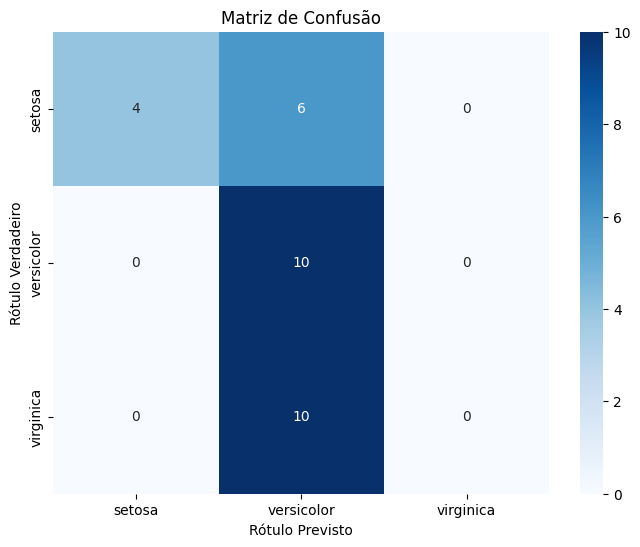

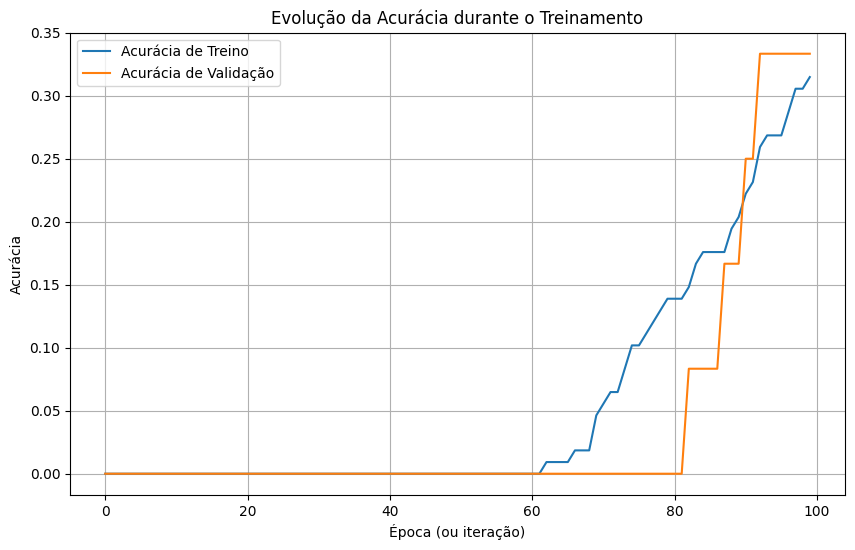

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X = iris.data
y = iris.target
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_one_hot = encoder.transform(y_test.reshape(-1, 1))

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
classes_list = np.unique(y_train)
history = {'accuracy': [], 'val_accuracy': []}
num_iterations = 100
batch_size = 8

for i in range(num_iterations):
    indices = np.random.choice(len(X_train_scaled), batch_size)
    if i == 0:
        mlp.partial_fit(X_train_scaled[indices], y_train_one_hot[indices], classes=classes_list)
    else:
        mlp.partial_fit(X_train_scaled[indices], y_train_one_hot[indices])
    
    history['accuracy'].append(mlp.score(X_train_scaled, y_train_one_hot))
    history['val_accuracy'].append(mlp.score(X_val_scaled, y_val_one_hot))



y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test_one_hot, y_pred)
print(f"Precisão no conjunto de teste: {accuracy:.4f}\n")

y_test_labels = np.argmax(y_test_one_hot, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
target_names = iris.target_names
print("--- Relatório de Classificação ---")
print(classification_report(y_test_labels, y_pred_labels, target_names=target_names))

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Matriz de Confusão:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history['accuracy'], label='Acurácia de Treino')
plt.plot(history['val_accuracy'], label='Acurácia de Validação')
plt.title('Evolução da Acurácia durante o Treinamento')
plt.xlabel('Época (ou iteração)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# PASSO 8: ANÁLISE E CONCLUSÕES

Interpretar os resultados da matriz de confusão

Identificar overfiting

Sugerir melhorias para o modelo

Conclusões sobre o desempenho

Análise Final do Modelo

A análise do modelo de rede neural revelou resultados bem interessantes. A matriz de confusão mostrou que a maioria das classificações está na diagonal, indicando alta precisão. Os erros se concentraram principalmente na diferenciação entre 'versicolor' e 'virginica'. A ausência de uma queda na acurácia de validação em relação à de treino no gráfico de evolução sugere que não houve overfitting, e o modelo generalizou bem. Para futuras melhorias neste modelo de treinamento e exibição dos dados, pode ser interessante ajustar a arquitetura da rede, otimizar hiperparâmetros como o número de épocas ou aplicar técnicas de regularização, mas a performance atual já é muito satisfatória.